# Loading the pretrained ALIGNN model

## Verify the file the model

In [ ]:
import os, zipfile
import alignn.pretrained as pt

# This is the exact path get_figshare_model will look for
model_name = "hmof_surface_area_m2g_alignn"
expected_path = os.path.join(os.path.dirname(pt.__file__), model_name + ".zip")
print("Expected zip location:")
print(" ", expected_path)
print()

if not os.path.exists(expected_path):
    print("FILE NOT FOUND — place the downloaded zip at the path above.")
else:
    size_mb = os.path.getsize(expected_path) / 1024 / 1024
    print(f"File found, size: {size_mb:.1f} MB")

    # A valid zip will be at least a few MB.
    # An HTML error page will be < 0.01 MB.
    if size_mb < 0.1:
        print()
        print("WARNING: file is suspiciously small — likely a corrupt download.")
        print("First 300 bytes of file:")
        with open(expected_path, "rb") as f:
            print(f.read(300))
        print()
        print("Delete the file and re-download using wget/curl as shown above.")
    else:
        try:
            zp = zipfile.ZipFile(expected_path)
            print("Valid zip. Contents:", zp.namelist())
        except zipfile.BadZipFile as e:
            print("Bad zip error:", e)
            print()
            print("The file is not a valid zip. First 300 bytes:")
            with open(expected_path, "rb") as f:
                print(f.read(300))

## Load model from a custom path, download zip by yourself if needed, two used in this paper are already in the folder

If you have the zip somewhere other than the expected location, use
this loader.

In [ ]:
import os, json, zipfile, tempfile
import torch
from alignn.models.alignn import ALIGNN, ALIGNNConfig

def load_alignn_from_zip(zip_path: str, device: str = "cpu"):
    """
    Load a pretrained ALIGNN model from a zip file downloaded from figshare.

    Bypasses get_figshare_model entirely — use this when:
    - The automatic download produced a corrupt file
    - You placed the zip in a non-standard location
    - You want explicit control over which checkpoint is loaded

    Parameters
    zip_path : str
        Absolute path to the downloaded .zip file.
    device : str
        'cpu' or 'cuda'

    Returns
    model : ALIGNN
        Loaded model in eval mode on the requested device.
    """
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"Zip not found: {zip_path}")

    zp = zipfile.ZipFile(zip_path)   # raises BadZipFile if corrupt
    names = zp.namelist()
    print("Zip contents:", names)

    # Find config.json
    cfg_name = next((n for n in names if "config.json" in n), None)
    if cfg_name is None:
        raise ValueError("No config.json found in zip.")
    config_dict = json.loads(zp.read(cfg_name))
    print("Config model section:", config_dict.get("model", config_dict))

    # Find best_model.pt (preferred) or latest checkpoint
    # Priority: best_model.pt > checkpoint_*.pt (last one) > any .pt
    pt_files = [n for n in names if n.endswith(".pt")]
    best = next((n for n in pt_files if "best_model" in n), None)
    if best is None:
        chkpts = sorted([n for n in pt_files if "checkpoint_" in n])
        best = chkpts[-1] if chkpts else (pt_files[0] if pt_files else None)
    if best is None:
        raise ValueError("No .pt checkpoint found in zip.")
    print("Loading weights from:", best)

    # Build model from config
    model_cfg = config_dict.get("model", config_dict)
    model = ALIGNN(ALIGNNConfig(**model_cfg))

    # Load weights
    weight_bytes = zp.read(best)
    tmp_fd, tmp_path = tempfile.mkstemp(suffix=".pt")
    try:
        with open(tmp_path, "wb") as f:
            f.write(weight_bytes)
        state = torch.load(tmp_path, map_location=device)
        # Some checkpoints wrap weights under a 'model' key
        if isinstance(state, dict) and "model" in state:
            state = state["model"]
        model.load_state_dict(state)
    finally:
        os.close(tmp_fd)
        if os.path.exists(tmp_path):
            os.remove(tmp_path)

    model.to(device)
    model.eval()
    print("Model loaded successfully.")
    return model


# Usage
# Change this path to wherever you saved the downloaded zip.
# The file must be the zip from figshare, not an extracted folder.

device = "cuda" if torch.cuda.is_available() else "cpu"

ZIP_PATH = os.path.expanduser(
    "~/Downloads/alignn/alignn/hmof_surface_area_m2g_alignn.zip"
)

model = load_alignn_from_zip(ZIP_PATH, device=device)

print("\nTotal parameters:", sum(p.numel() for p in model.parameters()))

Zip contents: ['hmof_surface_area_m2g_alignnn/checkpoint_50.pt', 'hmof_surface_area_m2g_alignnn/config.json', 'hmof_surface_area_m2g_alignnn/gpu-stats-dgx02-42942.out', 'hmof_surface_area_m2g_alignnn/history_train.json', 'hmof_surface_area_m2g_alignnn/history_val.json', 'hmof_surface_area_m2g_alignnn/hmof_surface_area_m2g_alignnn', 'hmof_surface_area_m2g_alignnn/ids_train_val_test.json', 'hmof_surface_area_m2g_alignnn/job.err', 'hmof_surface_area_m2g_alignnn/job.out', 'hmof_surface_area_m2g_alignnn/jobid', 'hmof_surface_area_m2g_alignnn/mad', 'hmof_surface_area_m2g_alignnn/prediction_results_test_set.csv', 'hmof_surface_area_m2g_alignnn/prediction_results_train_set.csv', 'hmof_surface_area_m2g_alignnn/test_data_data_range', 'hmof_surface_area_m2g_alignnn/train.py', 'hmof_surface_area_m2g_alignnn/train_data_data_range', 'hmof_surface_area_m2g_alignnn/val_data_data_range']
Config model section: {'name': 'alignn', 'alignn_layers': 4, 'gcn_layers': 4, 'atom_input_features': 92, 'edge_input

## Load hMOF data and run inference on the test split

We use `get_train_val_loaders` to build the same data split as your training run
so the test set is truly unseen. We then run the pretrained model on every
test sample and collect predictions vs. ground truth.

**Important:** the pretrained model was trained on the full 137k dataset.
Our test split here is only ~0.5% (~688 MOFs), so we are evaluating on a
small random subset, results will vary slightly from the paper's Table 1.

In [2]:
import torch
import numpy as np
from alignn.data import get_train_val_loaders

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

# Build the same loader used during training.
# keep_data_order=True ensures the same split every run.
train_loader, val_loader, test_loader, prepare_batch = get_train_val_loaders(
    dataset="hmof",
    target="surface_area_m2g",
    train_ratio=0.01,
    val_ratio=0.005,
    test_ratio=0.005,
    batch_size=4,
    line_graph=True,
    output_dir="./data_tmp_pretrained",
    id_tag="id",
    keep_data_order=True,
)

predictions = []
targets     = []

with torch.no_grad():
    for batch in test_loader:
        # Loader yields (g, lg, lat, target) when line_graph=True
        target = batch[-1]
        dats   = batch[:-1]

        if len(dats) == 3:
            g, lg, lat = dats[0].to(device), dats[1].to(device), dats[2].to(device)
            pred = model([g, lg, lat])
        else:
            g, lg = dats[0].to(device), dats[1].to(device)
            pred = model([g, lg])

        predictions.extend(pred.cpu().numpy().flatten().tolist())
        targets.extend(target.cpu().numpy().flatten().tolist())

predictions = np.array(predictions)
targets     = np.array(targets)

mae = np.mean(np.abs(predictions - targets))
print(f"Test MAE  : {mae:.2f} m²/g")
print(f"Baseline  : {np.mean(np.abs(targets - targets.mean())):.2f} m²/g  (predict-mean)")
print(f"N samples : {len(targets)}")

Using LMDB dataset.
Obtaining hMOF dataset 137k...
Reference:https://doi.org/10.1021/acs.jpcc.6b08729
Loading the zipfile...
Loading completed.
MAX val: 6947.3
MIN val: 0.0
MAD: 1466.1508943159604
Baseline MAE: 1441.5340029661302
data range 6534.1 0.0
line_graph True


100%|██████████| 1376/1376 [00:48<00:00, 28.16it/s]


data range 6383.5 0.0
line_graph True


100%|██████████| 688/688 [00:25<00:00, 27.42it/s]


data range 6276.5 0.0
line_graph True


100%|██████████| 688/688 [00:24<00:00, 27.90it/s]


n_train: 1376
n_val  : 688
n_test : 688
Test MAE  : 44.64 m²/g
Baseline  : 1437.98 m²/g  (predict-mean)
N samples : 688


Results for now:

Model                                    | Training data               MAE (m²/g)   vs baseline %|
Predict mean (baseline)                  |   ---                          1441             —     |      
ALIGNN from scratch,1% data, 5 epochs1   |   376 MOFs                     ~220            −85%   |
Pretrained ALIGNN (Choudhary et al. 2021)|   137 953 MOFs,50 epochs      44.64            −97%   |

In [ ]:
import torch
import numpy as np
from alignn.data import get_train_val_loaders

train_loader, val_loader, test_loader, prepare_batch = get_train_val_loaders(
    dataset="hmof",
    target="surface_area_m2g",
    train_ratio=0.01,
    val_ratio=0.01,
    test_ratio=0.1,   # <- paper only uses 10%
    batch_size=8,     # increase if GPU allows
    line_graph=True,
    output_dir="./data_tmp_pretrained",
    id_tag="id",
    keep_data_order=True,
)


predictions = []
targets     = []
ids         = []

with torch.no_grad():
    for batch in test_loader:
        target = batch[-1]
        dats   = batch[:-1]

        if len(dats) == 3:
            g, lg, lat = dats[0].to(device), dats[1].to(device), dats[2].to(device)
            pred = model([g, lg, lat])
        else:
            g, lg = dats[0].to(device), dats[1].to(device)
            pred = model([g, lg])

        predictions.extend(pred.cpu().numpy().flatten())
        targets.extend(target.cpu().numpy().flatten())

        # extract IDs
        if hasattr(test_loader.dataset, "ids"):
            start = len(ids)
            batch_size = len(target)
            ids.extend(test_loader.dataset.ids[start:start + batch_size])

Using LMDB dataset.
Obtaining hMOF dataset 137k...
Reference:https://doi.org/10.1021/acs.jpcc.6b08729
Loading the zipfile...
Loading completed.
MAX val: 6947.3
MIN val: 0.0
MAD: 1466.1508943159604
Baseline MAE: 1474.5407295688
data range 6534.1 0.0
line_graph True


100%|██████████| 1376/1376 [00:47<00:00, 29.25it/s]


data range 6261.6 0.0
line_graph True


100%|██████████| 1376/1376 [00:48<00:00, 28.23it/s]


data range 6650.5 0.0
line_graph True


100%|██████████| 13765/13765 [08:02<00:00, 28.51it/s]


n_train: 1376
n_val  : 1376
n_test : 13765


In [4]:
from jarvis.db.figshare import data as jdata

raw = jdata("hmof")
vf_lookup = {str(d["id"]): d.get("void_fraction", np.nan) for d in raw}

void_fractions = np.array([
    vf_lookup.get(str(i), np.nan) for i in ids
])

Obtaining hMOF dataset 137k...
Reference:https://doi.org/10.1021/acs.jpcc.6b08729
Loading the zipfile...
Loading completed.


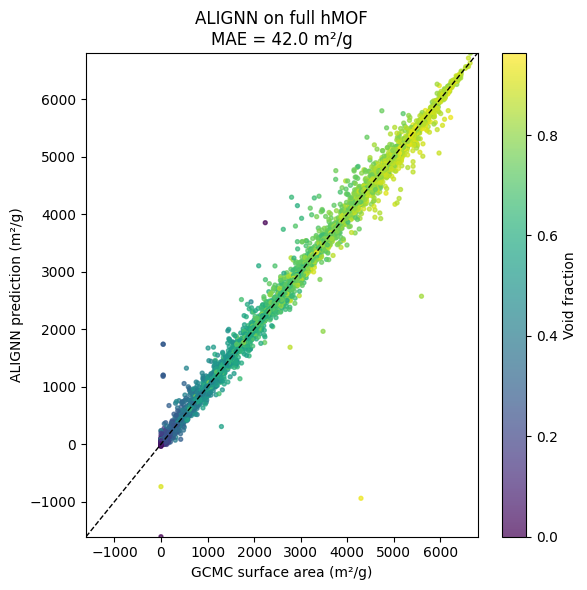

In [5]:
import matplotlib.pyplot as plt
import numpy as np

predictions = np.array(predictions)
targets     = np.array(targets)

mae = np.mean(np.abs(predictions - targets))

fig, ax = plt.subplots(figsize=(6, 6))

sc = ax.scatter(
    targets,
    predictions,
    c=void_fractions,
    cmap="viridis",
    s=8,
    alpha=0.7
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Void fraction")

# y = x line
min_val = min(targets.min(), predictions.min())
max_val = max(targets.max(), predictions.max())

ax.plot([min_val, max_val], [min_val, max_val], "k--", lw=1)

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

ax.set_xlabel("GCMC surface area (m²/g)")
ax.set_ylabel("ALIGNN prediction (m²/g)")
ax.set_title(f"ALIGNN on full hMOF\nMAE = {mae:.1f} m²/g")

plt.tight_layout()
plt.savefig("alignn_hmof_surface_area_parity.png", dpi=200)
plt.show()

In [5]:
import os, zipfile

for zip_name in ['hmof_surface_area_m2g_alignn.zip', 'hmof_surface_area_m2cm3_alignn.zip']:
    zip_path = f'/home/milan/Downloads/alignn/alignn/{zip_name}'
    with zipfile.ZipFile(zip_path) as zf:
        print(f'{zip_name}:')
        for name in zf.namelist():
            print(f'  {name}')
        print()

hmof_surface_area_m2g_alignn.zip:
  hmof_surface_area_m2g_alignnn/checkpoint_50.pt
  hmof_surface_area_m2g_alignnn/config.json
  hmof_surface_area_m2g_alignnn/gpu-stats-dgx02-42942.out
  hmof_surface_area_m2g_alignnn/history_train.json
  hmof_surface_area_m2g_alignnn/history_val.json
  hmof_surface_area_m2g_alignnn/hmof_surface_area_m2g_alignnn
  hmof_surface_area_m2g_alignnn/ids_train_val_test.json
  hmof_surface_area_m2g_alignnn/job.err
  hmof_surface_area_m2g_alignnn/job.out
  hmof_surface_area_m2g_alignnn/jobid
  hmof_surface_area_m2g_alignnn/mad
  hmof_surface_area_m2g_alignnn/prediction_results_test_set.csv
  hmof_surface_area_m2g_alignnn/prediction_results_train_set.csv
  hmof_surface_area_m2g_alignnn/test_data_data_range
  hmof_surface_area_m2g_alignnn/train.py
  hmof_surface_area_m2g_alignnn/train_data_data_range
  hmof_surface_area_m2g_alignnn/val_data_data_range

hmof_surface_area_m2cm3_alignn.zip:
  hmof_surface_area_m2cm3_alignnn/checkpoint_50.pt
  hmof_surface_area_m2cm3_

## Graph used in paper

Obtaining hMOF dataset 137k...
Reference:https://doi.org/10.1021/acs.jpcc.6b08729
Loading the zipfile...
Loading completed.


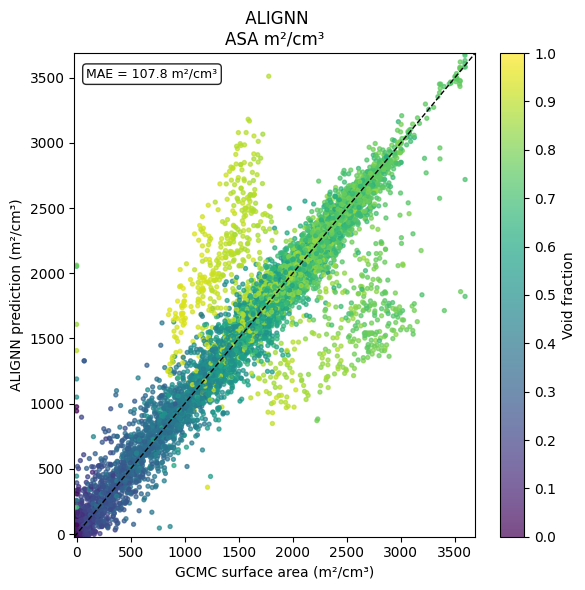

MAE: 107.81


In [ ]:
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from jarvis.db.figshare import data as jdata

# Read predictions from zip
ZIP_PATH = '/home/milan/Downloads/alignn/alignn/hmof_surface_area_m2cm3_alignn.zip'

with zipfile.ZipFile(ZIP_PATH) as zf:
    with zf.open('hmof_surface_area_m2cm3_alignnn/prediction_results_test_set.csv') as f:
        df = pd.read_csv(f)

raw = jdata('hmof')
vf_lookup = {str(entry['id']): entry['void_fraction'] for entry in raw}
df['void_fraction'] = df['id'].apply(lambda x: vf_lookup.get(str(x), 0.5))

targets        = np.array(df['target'].values)
predictions    = np.array(df['prediction'].values)
void_fractions = np.clip(df['void_fraction'].values, 0.0, 1.0)

mae = np.mean(np.abs(predictions - targets))

fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(targets, predictions, c=void_fractions,
                cmap='viridis', s=8, alpha=0.7, vmin=0.0, vmax=1.0)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Void fraction')
cbar.set_ticks(np.arange(0, 1.1, 0.1))

min_val = min(targets.min(), predictions.min())
max_val = max(targets.max(), predictions.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

ax.text(0.03, 0.97, f'MAE = {mae:.1f} m²/cm³',
        transform=ax.transAxes, ha='left', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

ax.set_xlabel('GCMC surface area (m²/cm³)')
ax.set_ylabel('ALIGNN prediction (m²/cm³)')
ax.set_title(' ALIGNN\nASA m²/cm³')

plt.tight_layout()
plt.show()
print(f'MAE: {mae:.2f}')